Random Forest Classification
----------------------------
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        18
Cyber Attack       1.00      1.00      1.00        22

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



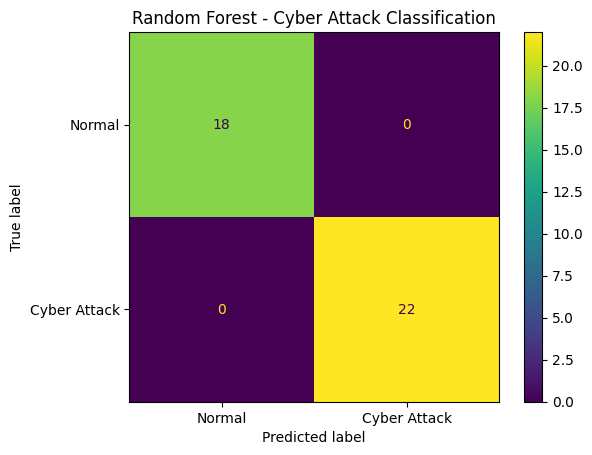

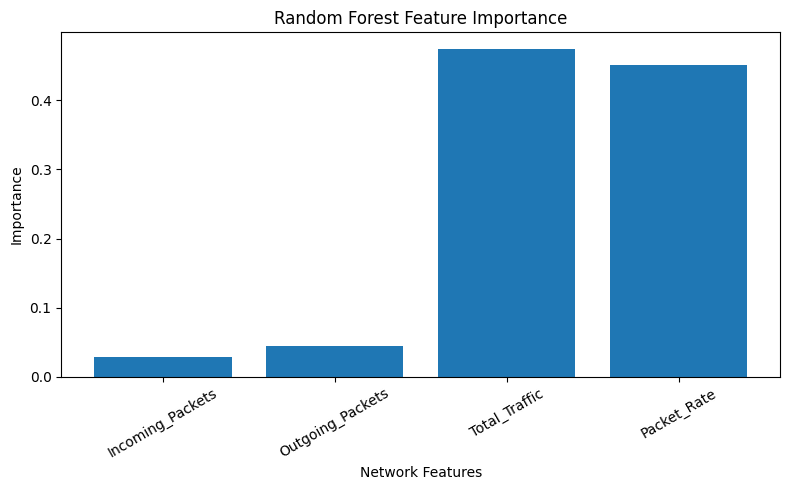

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create sample network traffic data
np.random.seed(42)

data = pd.DataFrame({
    "Incoming_Packets": np.random.randint(100, 2000, 200),
    "Outgoing_Packets": np.random.randint(50, 1000, 200),
    "Total_Traffic": np.random.randint(500, 5000, 200),
    "Packet_Rate": np.random.randint(20, 500, 200)
})

# Create attack labels
# High traffic and packet rate indicate possible attacks
data["Attack"] = (
    (data["Total_Traffic"] > 3500) |
    (data["Packet_Rate"] > 350)
).astype(int)

# Separate features and target
X = data[
    [
        "Incoming_Packets",
        "Outgoing_Packets",
        "Total_Traffic",
        "Packet_Rate"
    ]
]

y = data["Attack"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Classification")
print("----------------------------")
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Cyber Attack"]
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Cyber Attack"]
)

disp.plot()
plt.title("Random Forest - Cyber Attack Classification")
plt.show()

# Feature Importance
importance = model.feature_importances_

plt.figure(figsize=(8, 5))
plt.bar(X.columns, importance)
plt.title("Random Forest Feature Importance")
plt.xlabel("Network Features")
plt.ylabel("Importance")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()